# NLP Food Rating

This model is trained on the encoded ingredients from the PP_recipes.csv dataset and the numerical ratings from the interactions_train.csv dataset.

In [ ]:
# Inputs

# Version of model, this will be used as the saved model's suffix
version = '02'

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import keras
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Embedding

## Data Preparation

In [6]:
pp_recipes = pd.read_csv('../data/foodcom/PP_recipes.csv')
interactions_train = pd.read_csv('../data/foodcom/interactions_train.csv')
interactions_test = pd.read_csv('../data/foodcom/interactions_test.csv')

In [ ]:
pp_recipes.head()

,id,i,name_tokens,ingredient_tokens,steps_tokens,techniques,calorie_level,ingredient_ids
0,424415,23,"[40480, 37229, 2911, 1019, 249, 6878, 6878, 28...","[[2911, 1019, 249, 6878], [1353], [6953], [153...","[40480, 40482, 21662, 481, 6878, 500, 246, 161...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0,"[389, 7655, 6270, 1527, 3406]"
1,146223,96900,"[40480, 18376, 7056, 246, 1531, 2032, 40481]","[[17918], [25916], [2507, 6444], [8467, 1179],...","[40480, 40482, 729, 2525, 10906, 485, 43, 8393...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0,"[2683, 4969, 800, 5298, 840, 2499, 6632, 7022,..."
2,312329,120056,"[40480, 21044, 16954, 8294, 556, 10837, 40481]","[[5867, 24176], [1353], [6953], [1301, 11332],...","[40480, 40482, 8240, 481, 24176, 296, 1353, 66...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",1,"[1257, 7655, 6270, 590, 5024, 1119, 4883, 6696..."
3,74301,168258,"[40480, 10025, 31156, 40481]","[[1270, 1645, 28447], [21601], [27952, 29471, ...","[40480, 40482, 5539, 21601, 1073, 903, 2324, 4...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,"[7940, 3609, 7060, 6265, 1170, 6654, 5003, 3561]"
4,76272,109030,"[40480, 17841, 252, 782, 2373, 1641, 2373, 252...","[[1430, 11434], [1430, 17027], [1615, 23, 695,...","[40480, 40482, 14046, 1430, 11434, 488, 17027,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0,"[3484, 6324, 7594, 243]"


In [ ]:
interactions_train.head()

,user_id,recipe_id,date,rating,u,i
0,2046,4684,2000-02-25,5.0,22095,44367
1,2046,517,2000-02-25,5.0,22095,87844
2,1773,7435,2000-03-13,5.0,24732,138181
3,1773,278,2000-03-13,4.0,24732,93054
4,2046,3431,2000-04-07,5.0,22095,101723


In [ ]:
print('There are ', interactions_train['recipe_id'].value_counts().shape[0], ' unique recipe ids in the training data')

There are  160901  unique recipe ids in the training data


In [ ]:
# Get average rating of each recipe
agg_ratings = interactions_train.groupby('recipe_id').agg({'rating': 'mean'})
agg_ratings['rating'] = agg_ratings['rating'].round()
agg_ratings

,rating
recipe_id,
38,4.0
40,5.0
45,4.0
46,5.0
49,4.0
...,...
536729,5.0
536990,5.0
537175,5.0


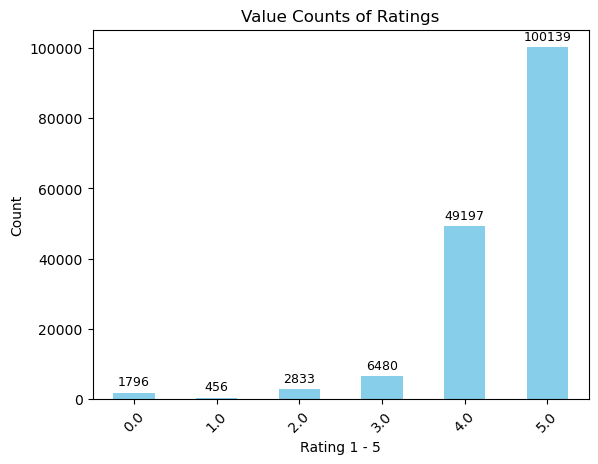

In [14]:
counts = agg_ratings['rating'].value_counts().sort_index()
ax = counts.plot(kind='bar', color='skyblue')
plt.xlabel('Rating 1 - 5')
plt.ylabel('Count')
plt.title('Value Counts of Ratings')
plt.xticks(rotation=45)

# add labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                xy=(p.get_x() + p.get_width() / 2, height), 
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=9)
plt.show()

In [ ]:
agg_ratings.value_counts()

rating
5.0       100139
4.0        49197
3.0         6480
2.0         2833
0.0         1796
1.0          456
Name: count, dtype: int64

In [ ]:
# Join the recipes with the ratings
renamed_col_recipes = pp_recipes.rename(columns={'id': 'recipe_id'})
recipes_ratings = renamed_col_recipes.join(agg_ratings, on='recipe_id', how='inner')

In [16]:
recipes_ratings.head()

,recipe_id,i,name_tokens,ingredient_tokens,steps_tokens,techniques,calorie_level,ingredient_ids,rating
0,424415,23,"[40480, 37229, 2911, 1019, 249, 6878, 6878, 28...","[[2911, 1019, 249, 6878], [1353], [6953], [153...","[40480, 40482, 21662, 481, 6878, 500, 246, 161...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0,"[389, 7655, 6270, 1527, 3406]",5.0
1,146223,96900,"[40480, 18376, 7056, 246, 1531, 2032, 40481]","[[17918], [25916], [2507, 6444], [8467, 1179],...","[40480, 40482, 729, 2525, 10906, 485, 43, 8393...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0,"[2683, 4969, 800, 5298, 840, 2499, 6632, 7022,...",5.0
2,312329,120056,"[40480, 21044, 16954, 8294, 556, 10837, 40481]","[[5867, 24176], [1353], [6953], [1301, 11332],...","[40480, 40482, 8240, 481, 24176, 296, 1353, 66...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",1,"[1257, 7655, 6270, 590, 5024, 1119, 4883, 6696...",4.0
3,74301,168258,"[40480, 10025, 31156, 40481]","[[1270, 1645, 28447], [21601], [27952, 29471, ...","[40480, 40482, 5539, 21601, 1073, 903, 2324, 4...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,"[7940, 3609, 7060, 6265, 1170, 6654, 5003, 3561]",5.0
4,76272,109030,"[40480, 17841, 252, 782, 2373, 1641, 2373, 252...","[[1430, 11434], [1430, 17027], [1615, 23, 695,...","[40480, 40482, 14046, 1430, 11434, 488, 17027,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0,"[3484, 6324, 7594, 243]",5.0


In [ ]:
# Process ingredients into list of integers
X_train = pd.Series(recipes_ratings['ingredient_ids'].apply(lambda x: list(map(int, x.replace('[', '').replace(']', '').split(','))))) 

y_train = pd.Series(recipes_ratings['rating'])

In [18]:
ingr_map = pd.read_pickle('../data/foodcom/ingr_map.pkl')
ingr_map = pd.DataFrame(ingr_map)
ingr_map.head()

,raw_ingr,raw_words,processed,len_proc,replaced,count,id
0,"medium heads bibb or red leaf lettuce, washed,...",13,"medium heads bibb or red leaf lettuce, washed,...",73,lettuce,4507,4308
1,mixed baby lettuces and spring greens,6,mixed baby lettuces and spring green,36,lettuce,4507,4308
2,romaine lettuce leaf,3,romaine lettuce leaf,20,lettuce,4507,4308
3,iceberg lettuce leaf,3,iceberg lettuce leaf,20,lettuce,4507,4308
4,red romaine lettuce,3,red romaine lettuce,19,lettuce,4507,4308


In [19]:
# Create a dictionary to process encoded ingredients
ingr_map_mappings = ingr_map.groupby(['replaced', 'id']).size().reset_index().drop(columns=[0])
ingr_dict = {}
for index, row in ingr_map_mappings.iterrows():
    ingr_dict[row['replaced']] = row['id']
ingr_dict

{"'s baking chocolate": 0,
 "'s chocolate chip": 1,
 "'s hugs chocolate": 2,
 "'s sauce": 3,
 "'s sour cream": 4,
 "'s spicy seasoning": 5,
 "'s syrup": 6,
 "'s teriyaki sauce": 7,
 '10 bean soup mix': 8,
 '10-minute success rice': 9,
 '100 proof vodka': 10,
 '15 bean mix': 11,
 '15 bean soup mix': 12,
 '3 bean mix': 13,
 '7-up': 14,
 '7-up soda': 15,
 'a.1. sauce': 16,
 'absinthe': 17,
 'absolut citron vodka': 18,
 'absolut kurant vodka': 19,
 'absolut mandarin vodka': 20,
 'absolut vodka': 21,
 'accent seasoning': 22,
 'aceto balsamico': 23,
 'acid blend': 24,
 'acini di pepe pastum': 25,
 'acorn squash': 26,
 'active starter': 27,
 'adobo sauce': 28,
 'adobo seasoning': 29,
 "adolph's meat tenderizer": 30,
 'advocaat': 31,
 'adzuki bean': 32,
 'after dinner mint': 33,
 'agar': 34,
 'agar-agar': 35,
 'agar-agar flake': 36,
 'agave': 37,
 'agave nectar': 38,
 'agave syrup': 39,
 'aguardiente': 40,
 'ahi': 41,
 'ahi tuna steak': 42,
 'aioli': 43,
 'aji yellow paste': 44,
 'ajinomoto': 

In [ ]:
# Save the ingredient mappings as a CSV to be read by the nlp module
ingr_map_mappings.to_csv('../data/ingr_map_mappings.csv')

In [27]:
X_train_padded = pad_sequences(X_train, maxlen=100, padding='pre', truncating='pre', value=0)

## Model Training

In [34]:
# training:
epochs = 10
batch_size = 128

# vector-space embedding:
n_dim = 64
n_unique_words = 50000 # as per Maas et al. (2011); may not be optimal
n_words_to_skip = 50 # ditto
max_review_length = 100
pad_type = trunc_type = 'pre'

# neural network architecture:
n_dense = 64
dropout = 0.5

In [31]:
early_stop = keras.callbacks.EarlyStopping(
  monitor="val_loss",
  mode="min",
  patience=3,
  restore_best_weights=True,
  verbose=1
)

In [32]:
model = Sequential()
model.add(Embedding(n_unique_words, n_dim))
model.add(Flatten())
model.add(Dense(n_dense, activation='relu'))
model.add(Dropout(dropout))
model.add(Dense(6, activation='softmax'))

In [33]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [35]:
model.fit(X_train_padded, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_split=0.1, callbacks=[early_stop])

Epoch 1/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 27s 23ms/step - accuracy: 0.6040 - loss: 0.9981 - val_accuracy: 0.6224 - val_loss: 0.9190
Epoch 2/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - accuracy: 0.6240 - loss: 0.9233 - val_accuracy: 0.6224 - val_loss: 0.9235
Epoch 3/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - accuracy: 0.6217 - loss: 0.8872 - val_accuracy: 0.6228 - val_loss: 0.9360
Epoch 4/10
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - accuracy: 0.6261 - loss: 0.8468 - val_accuracy: 0.6220 - val_loss: 0.9633
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


In [36]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 64)        │     3,200,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       409,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,830,164 (41.31 MB)

 Trainable params: 3,610,054 (13.77 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,220,110 (27.54 MB)

In [39]:
model.save(f"../models/nlp_food_rating_{version}.keras")